<a href="https://colab.research.google.com/github/QuintonPang/house-prices-advanced-regression-techniques/blob/main/House_Prices_Advanced_Regression_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Preprocessing data

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# preprocess both
df_1 = pd.read_csv('train.csv')
df_2 = pd.read_csv('test.csv')

if 'SalePrice' not in df_2.columns:
    df_2['SalePrice'] = 0

df = pd.concat([df_1,df_2], axis = 0)
df = df.set_index('Id')

In [ ]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# df with rows with at ;east one null value
df_null = df[df.isnull().sum()[df.isnull().sum()>0].index]

df_null.head()

,MSZoning,LotFrontage,Alley,Utilities,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,BsmtQual,BsmtCond,...,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PoolQC,Fence,MiscFeature,SaleType
Id,,,,,,,,,,,,,,,,,,,,,
1,RL,65.0,NaN,AllPub,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,...,2003.0,RFn,2.0,548.0,TA,TA,NaN,NaN,NaN,WD
2,RL,80.0,NaN,AllPub,MetalSd,MetalSd,NaN,0.0,Gd,TA,...,1976.0,RFn,2.0,460.0,TA,TA,NaN,NaN,NaN,WD
3,RL,68.0,NaN,AllPub,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,...,2001.0,RFn,2.0,608.0,TA,TA,NaN,NaN,NaN,WD
4,RL,60.0,NaN,AllPub,Wd Sdng,Wd Shng,NaN,0.0,TA,Gd,...,1998.0,Unf,3.0,642.0,TA,TA,NaN,NaN,NaN,WD
5,RL,84.0,NaN,AllPub,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,...,2000.0,RFn,3.0,836.0,TA,TA,NaN,NaN,NaN,WD


<Axes: ylabel='Id'>

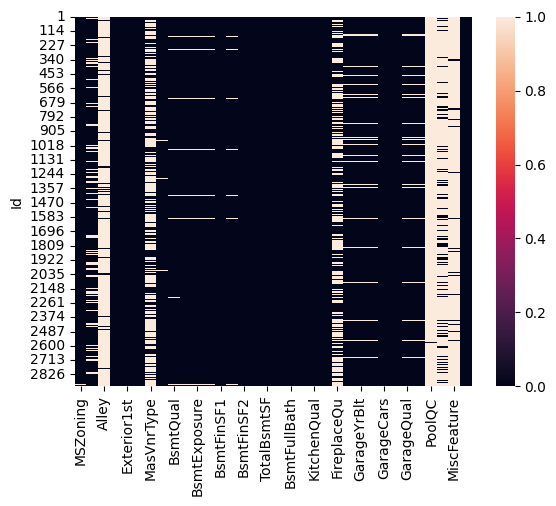

In [ ]:
sns.heatmap(df_null.isnull())

In [ ]:
# we can see columns with a lot of null values
df_objects = df[df.select_dtypes(include=['object']).columns] #  numeric df
df = df.drop(df[df_objects.isna().sum()[df_objects.isna().sum() > 1100].index],axis = 1) # drop entire columns from a DataFrame if they contain more than 1,100 missing (NaN) values

In [ ]:
df_objects = df_objects.drop(df_objects[df_objects.isna().sum()[df_objects.isna().sum() > 1100].index],axis = 1)

df_objects = df_objects.fillna("null")

df_objects_encoded = pd.get_dummies(df_objects)

df_objects_encoded.head()


,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,MSZoning_null,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,...,SaleType_New,SaleType_Oth,SaleType_WD,SaleType_null,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,True,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
2,False,False,False,True,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
3,False,False,False,True,False,False,False,True,True,False,...,False,False,True,False,False,False,False,False,True,False
4,False,False,False,True,False,False,False,True,True,False,...,False,False,True,False,True,False,False,False,False,False
5,False,False,False,True,False,False,False,True,True,False,...,False,False,True,False,False,False,False,False,True,False


In [ ]:
df_objects['MSZoning'].value_counts()

,count
MSZoning,
RL,2265
RM,460
FV,139
RH,26
C (all),25
null,4


In [ ]:
for i in df_objects_encoded.columns:
  if 'null' in i:
    df_objects_encoded = df_objects_encoded.drop(i, axis = 1)
    print(i)

MSZoning_null
Utilities_null
Exterior1st_null
Exterior2nd_null
BsmtQual_null
BsmtCond_null
BsmtExposure_null
BsmtFinType1_null
BsmtFinType2_null
Electrical_null
KitchenQual_null
Functional_null
GarageType_null
GarageFinish_null
GarageQual_null
GarageCond_null
SaleType_null


In [ ]:
new_df = pd.concat([df, df_objects_encoded],axis=1)  # combine original df with encoded one

In [ ]:
new_df = new_df.drop(df.select_dtypes(include=['object']),axis=1)
new_df.isna().sum()[new_df.isna().sum()>0] # numerical columns with null values

,0
LotFrontage,486
MasVnrArea,23
BsmtFinSF1,1
BsmtFinSF2,1
BsmtUnfSF,1
TotalBsmtSF,1
BsmtFullBath,2
BsmtHalfBath,2
GarageYrBlt,159
GarageCars,1


In [ ]:
# the logic used here to determine to use mean or mode to fill null values is by whether the column can have decimal values
Mode_columns = ['GarageCars','GarageYrBlt', 'BsmtFullBath','BsmtHalfBath']
Mean_columns = ['LotFrontage', 'MasVnrArea','BsmtFinSF1','BsmtFinSF2','TotalBsmtSF', 'BsmtUnfSF', 'GarageArea']

for i in Mode_columns:
  new_df[i] = new_df[i].fillna(new_df[i].mode()[0])

for i in Mean_columns:
  new_df[i] = new_df[i].fillna(np.round(new_df[i].mean()))

new_df.isna().sum()[new_df.isna().sum()>0]

,0


In [ ]:
training_data = new_df[0:len(df_1)]
testing_data = new_df[len(df_1):]
testing_data = testing_data.drop(columns='SalePrice')

Training Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
X = training_data.drop(columns='SalePrice')
y = training_data['SalePrice']
X_train , X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2)

X_train.shape, y_train.shape

((1168, 266), (1168, 1))

In [ ]:
model_1 = LinearRegression()
model_1.fit(X_train,y_train)
y_pred = model_1.predict(X_test)
print(mean_squared_error(y_test,y_pred))

2438474045.970566


In [ ]:
model_2= XGBRegressor(n_estimators=1000, learning_rate =0.1)
model_2.fit(X_train,y_train)
y_pred = model_2.predict(X_test)
print(mean_squared_error(y_test,y_pred))

680323136.0


In [ ]:
model_3 = RandomForestRegressor(n_estimators = 100)
model_3.fit(X_train,y_train)
y_pred = model_3.predict(X_test)
print(mean_squared_error(y_test,y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


1065789570.0733057


In [ ]:
model_final= XGBRegressor(n_estimators=1000, learning_rate =0.1)
model_final.fit(X,y)

3859.97509765625


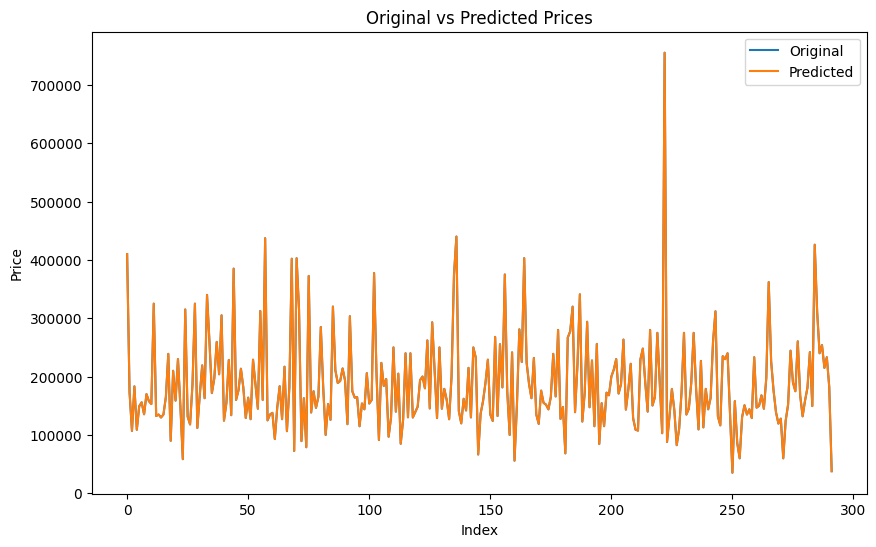

In [ ]:
sort_indices = np.argsort(y_test)

plt.figure(figsize=(10,6))
plt.plot(np.arange(len(y_test)), y_test, label = 'Original')
plt.plot(np.arange(len(y_test)), y_pred, label = 'Predicted')
plt.xlabel('Index')
plt.ylabel('Price')
plt.title('Original vs Predicted Prices')
plt.legend()
plt.show()

Prediction

In [ ]:
pred = model_final.predict(testing_data)

final = pd.DataFrame({'Id': testing_data.index, 'SalePrice': pred})
final.to_csv('submission.csv', index=False)